In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./data/cleaned_fake_real_news.csv')
df.head(5)

,title,text,subject,date,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [3]:
df.shape

(44689, 5)

In [4]:
# Drop 'subject' and 'date' columns
df.drop(columns=['subject', 'date'], inplace=True)
df.head(5)

,title,text,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,1


In [5]:
# trim any trailing spaces in the 'text' column
df['text'] = df['text'].str.strip()

# trim any trailing spaces in the 'title' column
df['title'] = df['title'].str.strip()

# merge the 'title' and 'text' columns into a new column called 'content'
df['content'] = df['title'] + ' ' + df['text']

In [6]:
# create a new dataframe with only the 'content' and 'target' columns
df_clean = df[['content', 'target']].copy()
# rename the 'target' column to 'label'
df_clean.rename(columns={'target': 'label'}, inplace=True)
# rename the 'content' column to 'news'
df_clean.rename(columns={'content': 'news'}, inplace=True)

# check the first 5 rows of the new dataframe
df_clean.head(5)

,news,label
0,Donald Trump Sends Out Embarrassing New Year’s...,1
1,Drunk Bragging Trump Staffer Started Russian C...,1
2,Sheriff David Clarke Becomes An Internet Joke ...,1
3,Trump Is So Obsessed He Even Has Obama’s Name ...,1
4,Pope Francis Just Called Out Donald Trump Duri...,1


In [7]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


# Custom stopwords (retain "not" and "can")
stop_words = set(stopwords.words('english')) - {'not', 'can'}

# Function for preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\'t", " not", text)  # Expand "can't" → "can not"
    text = re.sub(r'@\w+', '', text)  # Remove @name
    text = re.sub(r'[^a-zA-Z0-9\s\?]', '', text)  # Remove special characters except "?"
    text = re.sub(r'([^\w\s\?])', '', text)  # Remove punctuations except "?"
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces and trailing whitespaces
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return tokens

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [8]:
# Apply the cleaning function
df_clean['tokens'] = df_clean['news'].apply(clean_text)

In [9]:
df_clean.head(5)

,news,label,tokens
0,Donald Trump Sends Out Embarrassing New Year’s...,1,"[donald, trump, sends, embarrassing, new, year..."
1,Drunk Bragging Trump Staffer Started Russian C...,1,"[drunk, bragging, trump, staffer, started, rus..."
2,Sheriff David Clarke Becomes An Internet Joke ...,1,"[sheriff, david, clarke, becomes, internet, jo..."
3,Trump Is So Obsessed He Even Has Obama’s Name ...,1,"[trump, obsessed, even, obamas, name, coded, w..."
4,Pope Francis Just Called Out Donald Trump Duri...,1,"[pope, francis, called, donald, trump, christm..."


In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   news    44689 non-null  object
 1   label   44689 non-null  int64 
 2   tokens  44689 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [11]:
import matplotlib.pyplot as plt
from collections import Counter

# Count words separately for each class
def get_word_frequencies(df, class_label):
    class_tokens = df[df['label'] == class_label]['tokens'].explode()
    return Counter(class_tokens)

# define the function to plot word frequencies
def plot_word_frequencies(df, top_n=15):
    # Count words separately for each class
    fake_freq = get_word_frequencies(df, 1)  # change to 0 if numeric
    real_freq = get_word_frequencies(df, 0)  # change to 1 if numeric

    # Get most common words
    fake_common = fake_freq.most_common(top_n)
    real_common = real_freq.most_common(top_n)

    # Split into words and frequencies
    fake_words, fake_counts = zip(*fake_common)
    real_words, real_counts = zip(*real_common)

    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    # Fake news plot
    axs[0].barh(fake_words[::-1], fake_counts[::-1], color='red')
    axs[0].set_title('Top Words in FAKE News')
    axs[0].set_xlabel('Frequency')
    # Real news plot
    axs[1].barh(real_words[::-1], real_counts[::-1], color='green')
    axs[1].set_title('Top Words in REAL News')
    axs[1].set_xlabel('Frequency')
    plt.tight_layout()
    plt.show()

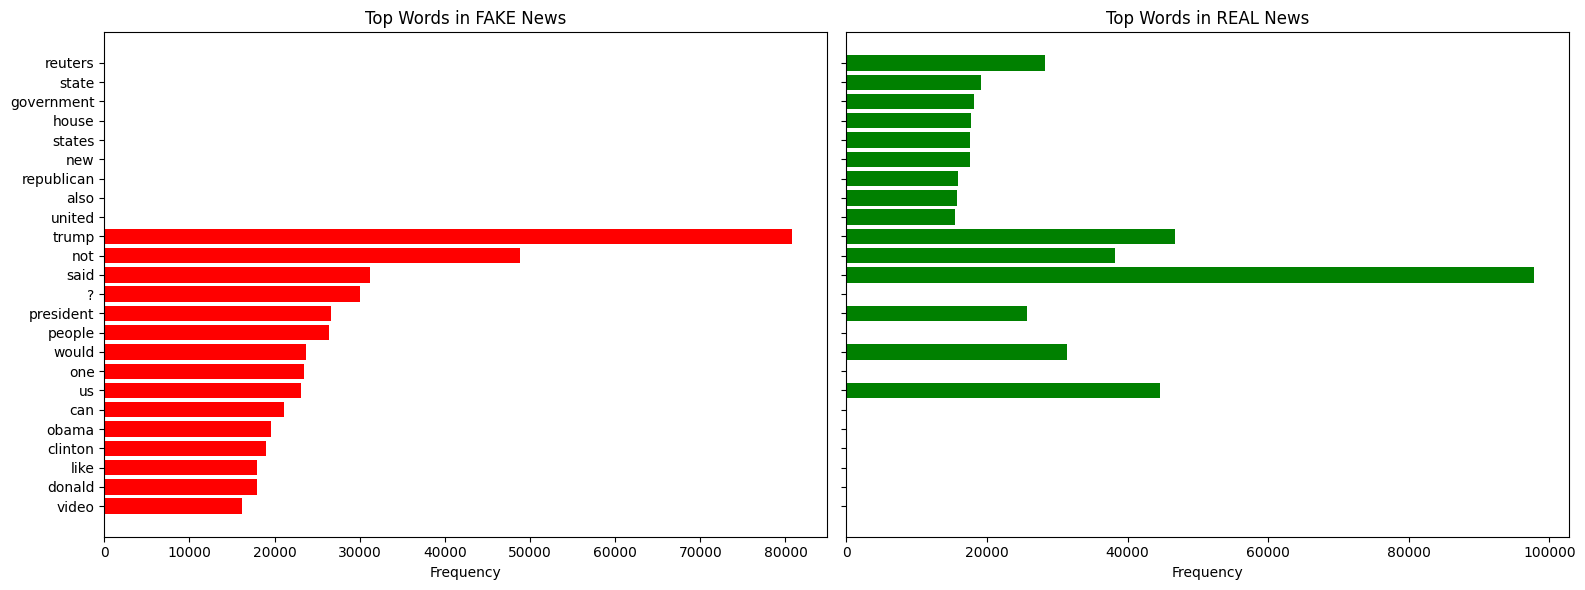

In [12]:
# Call the function to plot word frequencies
plot_word_frequencies(df_clean, top_n=15)

In [13]:
# Remove the word 'reuters' from the tokens
df_clean['tokens'] = df_clean['tokens'].apply(lambda tokens: [word for word in tokens if word != 'reuters'])

# Check the first 5 rows of the updated dataframe
df_clean.head(5)

,news,label,tokens
0,Donald Trump Sends Out Embarrassing New Year’s...,1,"[donald, trump, sends, embarrassing, new, year..."
1,Drunk Bragging Trump Staffer Started Russian C...,1,"[drunk, bragging, trump, staffer, started, rus..."
2,Sheriff David Clarke Becomes An Internet Joke ...,1,"[sheriff, david, clarke, becomes, internet, jo..."
3,Trump Is So Obsessed He Even Has Obama’s Name ...,1,"[trump, obsessed, even, obamas, name, coded, w..."
4,Pope Francis Just Called Out Donald Trump Duri...,1,"[pope, francis, called, donald, trump, christm..."


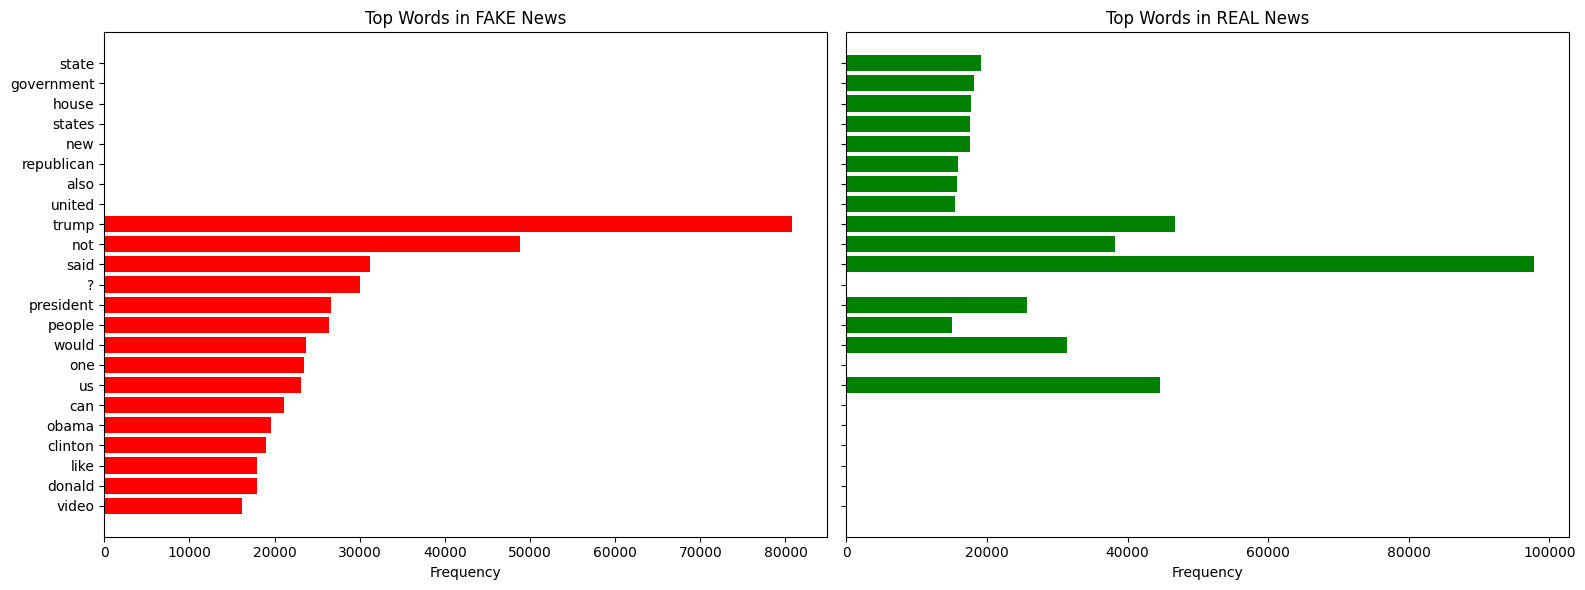

In [14]:
# Call the function to plot word frequencies
plot_word_frequencies(df_clean, top_n=15)

In [15]:
# rearrange the columns
df_clean = df_clean[['news', 'tokens', 'label']]
# check the first 5 rows of the new dataframe
df_clean.head(5)

,news,tokens,label
0,Donald Trump Sends Out Embarrassing New Year’s...,"[donald, trump, sends, embarrassing, new, year...",1
1,Drunk Bragging Trump Staffer Started Russian C...,"[drunk, bragging, trump, staffer, started, rus...",1
2,Sheriff David Clarke Becomes An Internet Joke ...,"[sheriff, david, clarke, becomes, internet, jo...",1
3,Trump Is So Obsessed He Even Has Obama’s Name ...,"[trump, obsessed, even, obamas, name, coded, w...",1
4,Pope Francis Just Called Out Donald Trump Duri...,"[pope, francis, called, donald, trump, christm...",1


In [16]:
df_model = df_clean.copy()

# drop the news column
df_model.drop(columns=['news'], inplace=True)

# create a new column 'text' by joining the tokens back into a string seperated by spaces
df_model['text'] = df_model['tokens'].apply(lambda x: ' '.join(x))

# rearrange the columns
df_model_clean = df_model[['text', 'label']]

# check the first 5 rows of the new dataframe
df_model_clean.head(5)

,text,label
0,donald trump sends embarrassing new years eve ...,1
1,drunk bragging trump staffer started russian c...,1
2,sheriff david clarke becomes internet joke thr...,1
3,trump obsessed even obamas name coded website ...,1
4,pope francis called donald trump christmas spe...,1


In [17]:
# extract target and features
X = df_model_clean['text']
y = df_model_clean['label']

# check the first 5 rows of the target and features
X.head(5), y.head(5)

(0    donald trump sends embarrassing new years eve ...
 1    drunk bragging trump staffer started russian c...
 2    sheriff david clarke becomes internet joke thr...
 3    trump obsessed even obamas name coded website ...
 4    pope francis called donald trump christmas spe...
 Name: text, dtype: object,
 0    1
 1    1
 2    1
 3    1
 4    1
 Name: label, dtype: int64)

In [18]:
X.shape, y.shape

((44689,), (44689,))

In [19]:
from sklearn.model_selection import train_test_split

# Assuming X and y are lists or numpy arrays
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [20]:
# print the shape of the training and testing sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (31282,), y_train shape: (31282,)


In [21]:
# print the shape of the testing sets
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_test shape: (13407,), y_test shape: (13407,)


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=6000, lowercase=False)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [23]:
X_train_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4241382 stored elements and shape (31282, 6000)>


------ Logistic Regression ------
Accuracy: 0.9835906615946893
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      6363
           1       0.99      0.98      0.98      7044

    accuracy                           0.98     13407
   macro avg       0.98      0.98      0.98     13407
weighted avg       0.98      0.98      0.98     13407



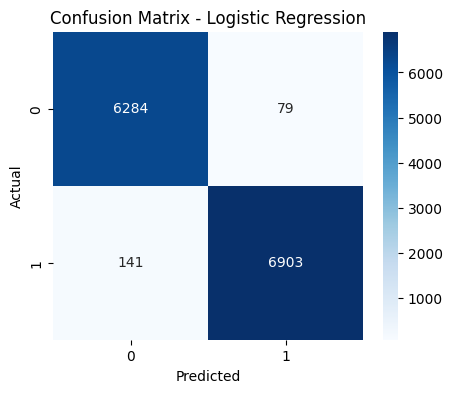


------ Naive Bayes ------
Accuracy: 0.9313791303050645
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93      6363
           1       0.93      0.94      0.93      7044

    accuracy                           0.93     13407
   macro avg       0.93      0.93      0.93     13407
weighted avg       0.93      0.93      0.93     13407



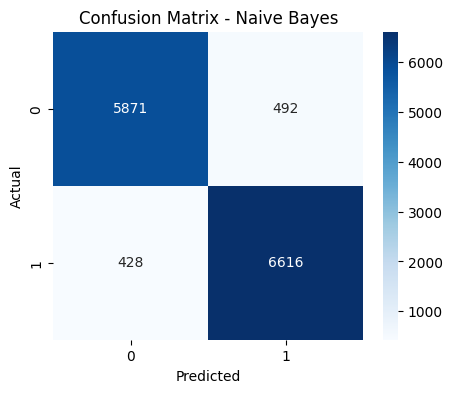

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB()
}

for name, model in models.items():
    print(f"\n------ {name} ------")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    # Text output
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [25]:
import shap

# Create a SHAP explainer for Logistic Regression (use the trained model and TF-IDF matrix as inputs)
explainer = shap.Explainer(models['Logistic Regression'], X_train_vec)  # X_train is the feature matrix from the training data
shap_values = explainer(X_test_vec)  # X_test is the feature matrix for the test set

# Visualize the SHAP values for a particular prediction (e.g., index 42 in the test set)
shap.initjs()

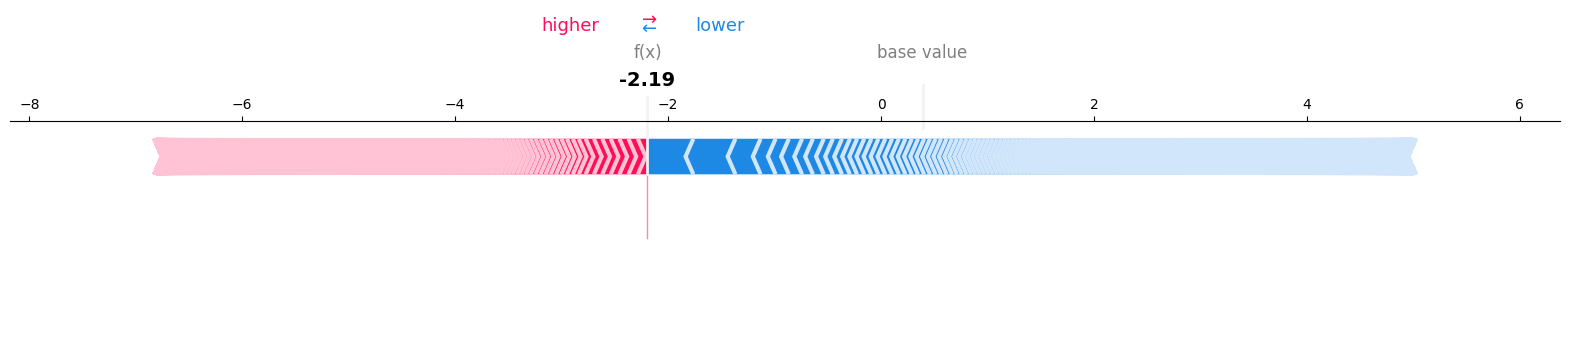

In [26]:
import matplotlib
shap.force_plot(shap_values[42], matplotlib=matplotlib)  # This will explain the prediction for the 42nd instance in the test set

In [30]:
import shap
import numpy as np

# Convert sparse matrix to dense (only for explanation, not recommended for large datasets)
X_train_dense = X_train_vec.toarray()

# Create explainer
explainer = shap.LinearExplainer(models['Logistic Regression'], X_train_dense, feature_perturbation="interventional")

# Explain predictions
shap_values = explainer.shap_values(X_train_dense)


c:\Users\u3253992\.conda\envs\py12\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


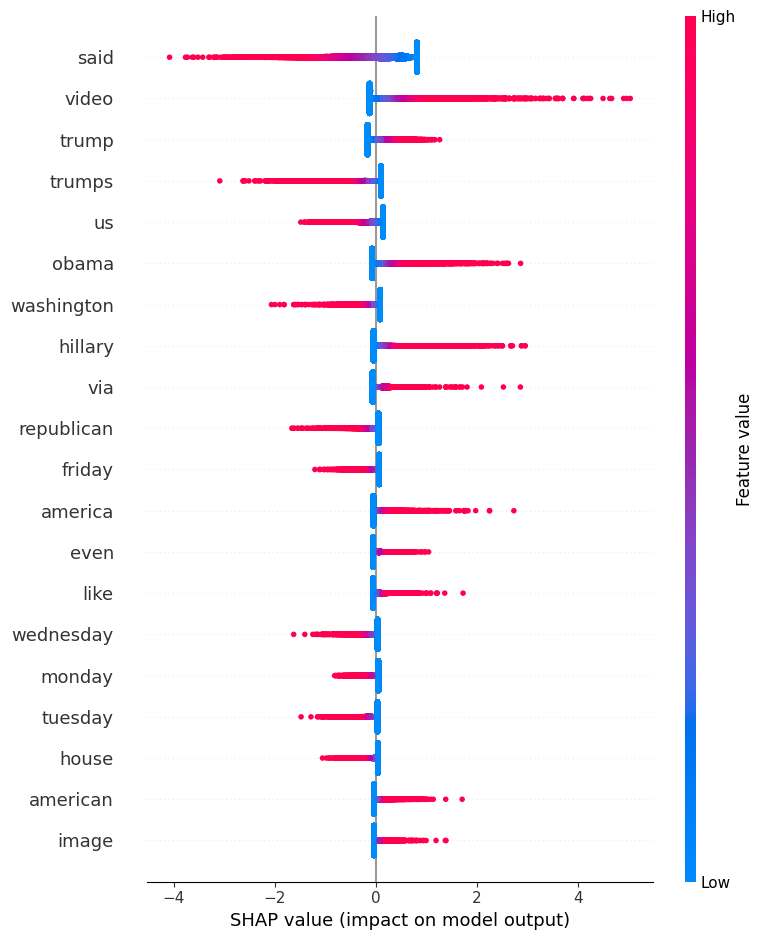

In [31]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Convert SHAP values to summary plot input
shap.summary_plot(shap_values, X_train_dense, feature_names=feature_names)


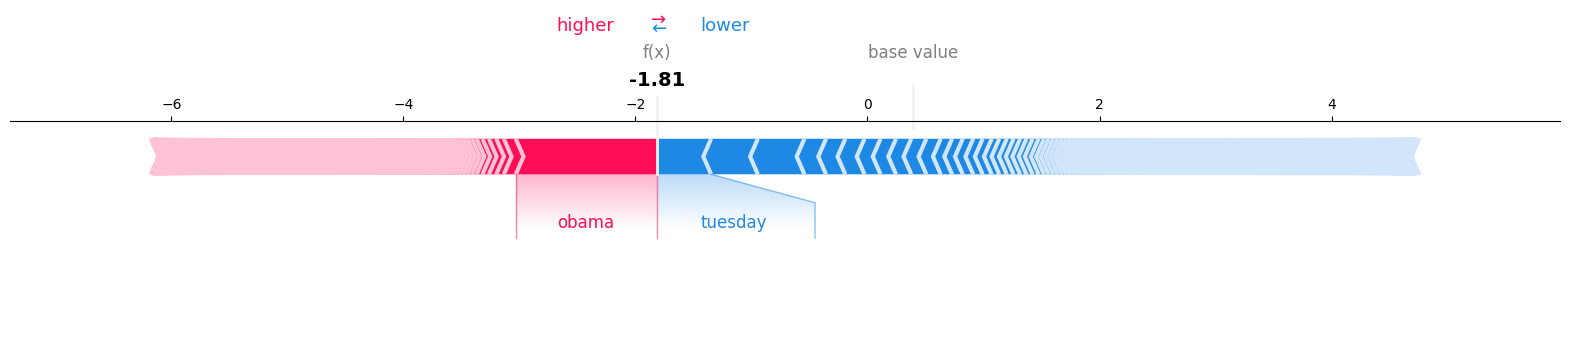

In [41]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[3],
    feature_names=feature_names,
    matplotlib=True
)


In [35]:
# Assuming 'vectorizer' is your TfidfVectorizer and 'model' is your trained Logistic Regression model

# Get the feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Get the coefficients of the Logistic Regression model
coefficients = models['Logistic Regression'].coef_.flatten()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Sort by the absolute value of the coefficient to get the most influential words
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

# Display top 10 words with the highest coefficients (most influential)
print(coef_df.head(20))


         feature  coefficient   abs_coef
4730        said   -18.282954  18.282954
5748       video    10.149281  10.149281
5742         via     8.616153   8.616153
5585      trumps    -8.435663   8.435663
5830  washington    -6.367075   6.367075
5860   wednesday    -5.776838   5.776838
5593     tuesday    -5.377669   5.377669
2729       image     5.282314   5.282314
3719       obama     5.137887   5.137887
2428         gop     5.105144   5.105144
5466    thursday    -5.059263   5.059263
2614     hillary     5.040040   5.040040
356      america     5.011088   5.011088
5697          us    -4.867191   4.867191
3570          mr     4.650339   4.650339
1997        even     4.635506   4.635506
2324      friday    -4.466123   4.466123
3532      monday    -4.220692   4.220692
4540  republican    -4.194674   4.194674
3225        like     4.162213   4.162213
